# Stability of Fama–French Factor Exposures Through Time

**Research question:** How stable are Fama–French factor exposures across different market regimes?

This notebook implements the Fama–French Three-Factor Model on an equal-weight portfolio of large-cap
U.S. equities:

$$R_p - R_f = \alpha + \beta_M (MKT - RF) + \beta_S \cdot SMB + \beta_H \cdot HML + \epsilon$$

**Workflow**
1. Download the three factors + risk-free rate from the Kenneth French Data Library
2. Download monthly adjusted prices from Yahoo Finance and build an equal-weight portfolio
3. Estimate the full-sample factor regression
4. Estimate rolling 36-month regressions to get time-varying alpha and betas
5. Compare exposures across market regimes (pre-COVID, COVID, 2022 tightening, AI rally)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import yfinance as yf

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

START = "2012-01-01"   # gives ~3 years of run-up before the first 36-month rolling estimate
WINDOW = 36            # rolling window in months

## Step 1 — Factor data (Kenneth French Data Library)

`F-F_Research_Data_Factors` contains monthly `Mkt-RF`, `SMB`, `HML` and `RF`, quoted in **percent**,
so we divide by 100 to match the decimal returns we compute from prices.

In [2]:
ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=START)[0]
ff = ff / 100.0   # percent -> decimal
print(f"Factors: {ff.index[0]} to {ff.index[-1]}  ({len(ff)} months)")
ff.tail()

Factors: 2012-01 to 2026-05  (173 months)


,Mkt-RF,SMB,HML,RF
Date,,,,
2026-01,0.0103,0.0213,0.0382,0.0030
2026-02,-0.0117,0.0023,0.0271,0.0028
2026-03,-0.0518,0.0042,0.0341,0.0029
2026-04,0.0995,0.0011,-0.0117,0.0029
2026-05,0.0490,-0.0169,-0.0215,0.0031


## Step 2 — Asset data and portfolio construction (Yahoo Finance)

15 large-cap U.S. equities across sectors, monthly adjusted closes. The portfolio is equal-weight,
rebalanced monthly (i.e. the simple cross-sectional mean of monthly returns).

In [3]:
TICKERS = ["AAPL", "MSFT", "NVDA", "JPM", "GS", "JNJ", "PFE", "XOM", "CVX",
           "PG", "KO", "WMT", "HD", "CAT", "DIS"]

prices = yf.download(TICKERS, start=START, interval="1mo", auto_adjust=True,
                     progress=False)["Close"]
rets = prices.pct_change().dropna(how="all")
rets.index = rets.index.to_period("M")
rets = rets[rets.index < pd.Timestamp.today().to_period("M")]   # drop partial current month

print(f"Asset returns: {rets.index[0]} to {rets.index[-1]}  ({len(rets)} months, {rets.shape[1]} stocks)")
rets.tail(3)

Asset returns: 2012-02 to 2026-06  (173 months, 15 stocks)


Ticker,AAPL,CAT,CVX,DIS,GS,HD,JNJ,JPM,KO,MSFT,NVDA,PFE,PG,WMT,XOM
Date,,,,,,,,,,,,,,,
2026-04,0.0692,0.2588,-0.0657,0.0765,0.0919,-0.0003,-0.0597,0.0703,0.0356,0.1016,0.1443,-0.0491,0.0260,0.0616,-0.0904
2026-05,0.1511,-0.0160,-0.0475,-0.0185,0.1102,-0.0355,-0.0140,-0.0444,0.0032,0.1065,0.0580,-0.0033,-0.0240,-0.1210,-0.0524
2026-06,-0.0727,0.2158,-0.0915,-0.0476,-0.0095,0.1204,0.1271,0.0936,0.0352,-0.1715,-0.0512,-0.0802,0.0215,-0.0215,-0.0588


### Excess returns

Equal-weight portfolio return $R_p$, then excess return $R_p - R_f$ using the T-bill rate from the
French library. Factor and portfolio series are aligned on their common monthly index.

In [4]:
port = rets.mean(axis=1).rename("Rp")   # equal-weight portfolio

data = pd.concat([port, ff], axis=1, join="inner").dropna()
data["Rp_excess"] = data["Rp"] - data["RF"]

print(f"Aligned sample: {data.index[0]} to {data.index[-1]}  ({len(data)} months)")
data[["Rp", "RF", "Rp_excess", "Mkt-RF", "SMB", "HML"]].describe()

Aligned sample: 2012-02 to 2026-05  (172 months)


,Rp,RF,Rp_excess,Mkt-RF,SMB,HML
count,172.0000,172.0000,172.0000,172.0000,172.0000,172.0000
mean,0.0152,0.0013,0.0139,0.0112,-0.0016,0.0001
std,0.0414,0.0016,0.0414,0.0421,0.0257,0.0338
min,-0.1083,0.0000,-0.1095,-0.1337,-0.0593,-0.1383
25%,-0.0118,0.0000,-0.0119,-0.0112,-0.0201,-0.0190
50%,0.0209,0.0003,0.0198,0.0149,-0.0005,-0.0029
75%,0.0424,0.0024,0.0414,0.0343,0.0120,0.0174
max,0.1358,0.0048,0.1335,0.1360,0.0714,0.1286


## Step 3 — Full-sample factor regression

OLS of portfolio excess returns on the three factors over the whole sample. This is the "static"
model whose stability we are questioning.

**Standard errors:** monthly return residuals show autocorrelation and heteroskedasticity, which
makes classical OLS standard errors too small. We therefore report **Newey–West (HAC) robust
standard errors**, with the lag length set by the standard rule of thumb
$\lfloor 4(T/100)^{2/9} \rfloor$. The coefficient estimates are unchanged — only the standard
errors, t-stats and p-values are corrected.

In [5]:
def nw_lags(nobs):
    """Newey-West rule-of-thumb lag length."""
    return max(1, int(np.floor(4 * (nobs / 100) ** (2 / 9))))

FACTORS = ["Mkt-RF", "SMB", "HML"]
X = sm.add_constant(data[FACTORS])
y = data["Rp_excess"]

full_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags(len(data))})
print(f"Newey-West lags: {nw_lags(len(data))}")
print(full_model.summary())

Newey-West lags: 4
                            OLS Regression Results                            
Dep. Variable:              Rp_excess   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     250.1
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           1.02e-61
Time:                        18:14:12   Log-Likelihood:                 500.31
No. Observations:                 172   AIC:                            -992.6
Df Residuals:                     168   BIC:                            -980.0
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0030      0.001 

In [6]:
alpha_m = full_model.params["const"]
print(f"Full-sample results")
print(f"  Alpha:      {alpha_m:+.4%} per month  ({(1 + alpha_m)**12 - 1:+.2%} annualised, "
      f"p = {full_model.pvalues['const']:.3f})")
for f in FACTORS:
    print(f"  {f:8s} beta: {full_model.params[f]:+.3f}  (p = {full_model.pvalues[f]:.4f})")
print(f"  R-squared:  {full_model.rsquared:.3f}")
print("  (p-values are Newey-West HAC robust)")

Full-sample results
  Alpha:      +0.2990% per month  (+3.65% annualised, p = 0.001)
  Mkt-RF   beta: +0.946  (p = 0.0000)
  SMB      beta: -0.183  (p = 0.0000)
  HML      beta: +0.202  (p = 0.0000)
  R-squared:  0.898
  (p-values are Newey-West HAC robust)


### A caution on interpreting alpha

The estimated alpha should **not** be read as evidence of genuine outperformance, for two reasons:

- **Survivorship bias** — the tickers were chosen *today*, so every stock in the portfolio is a
  firm that survived (and mostly thrived) over the whole sample. Firms that were delisted,
  acquired under distress, or shrank out of the large-cap universe are excluded by construction,
  which mechanically inflates the portfolio's historical return and hence alpha.
- **Stock-selection (look-ahead) bias** — the list is tilted toward names we now know did well
  (e.g. NVDA, AAPL, MSFT). A portfolio formed in 2012 without hindsight would likely have held
  different names.

For this project that is acceptable — the object of interest is the *stability of the betas*, not
the level of alpha. But any positive, significant alpha here says more about how the sample was
selected than about market inefficiency.

## Step 4 — Rolling 36-month regressions

Re-estimate the same regression in overlapping 36-month windows. Each point in the resulting series
is the loading estimated from the *previous three years* of data, so it shows how exposures drift
as the estimation window moves through different market environments.

**Overlap caveat:** consecutive windows share 35 of their 36 months, so the rolling estimates are
**highly serially dependent, not independent observations**. This has two consequences: (1) the
plotted paths look smooth by construction, and short-lived shocks (e.g. the COVID crash) influence
the estimates for a full 36 months after they occur; (2) you cannot apply standard inference to the
*path* of rolling estimates — e.g. counting how many windows lie outside a confidence band
overstates significance. The rolling plots are best read as a descriptive diagnostic of drift, with
formal inference left to the full-sample and sub-period regressions.

In [7]:
rols = RollingOLS(y, X, window=WINDOW).fit()

PARAM_NAMES = {"const": "Alpha", "Mkt-RF": "Market Beta", "SMB": "SMB Beta", "HML": "HML Beta"}
rolling_params = rols.params.dropna().rename(columns=PARAM_NAMES)
rolling_se = rols.bse.dropna().rename(columns=PARAM_NAMES)
rolling_r2 = rols.rsquared.dropna().rename("R-squared")

print(f"Rolling estimates: {rolling_params.index[0]} to {rolling_params.index[-1]} "
      f"({len(rolling_params)} windows)")
rolling_params.tail(3)

Rolling estimates: 2015-01 to 2026-05 (137 windows)


,Alpha,Market Beta,SMB Beta,HML Beta
Date,,,,
2026-03,0.0023,0.9370,-0.1299,0.3003
2026-04,0.0021,0.8371,-0.0603,0.2890
2026-05,0.0020,0.7973,-0.0126,0.2795


### Market regimes

Shaded bands used in the plots and for the sub-period regressions below.

In [8]:
REGIMES = {
    "Pre-COVID":            ("2015-01", "2020-01", "tab:blue"),
    "COVID disruption":     ("2020-02", "2021-12", "tab:red"),
    "2022 rate tightening": ("2022-01", "2022-12", "tab:orange"),
    "AI-driven rally":      ("2023-01", str(data.index[-1]), "tab:green"),
}

def shade_regimes(ax):
    for name, (s, e, c) in REGIMES.items():
        ax.axvspan(pd.Period(s, "M").to_timestamp(),
                   pd.Period(e, "M").to_timestamp(how="end"),
                   color=c, alpha=0.10)

### Time-series plots of rolling loadings

Solid line = point estimate; shaded band = ±1.96 standard errors (95% confidence band). Note these
bands use classical OLS standard errors (`RollingOLS` does not support HAC), so they are slightly
too narrow; combined with the window-overlap caveat above, read them as descriptive.
Remember each estimate is backward-looking over 36 months, so regime effects show up with a lag.

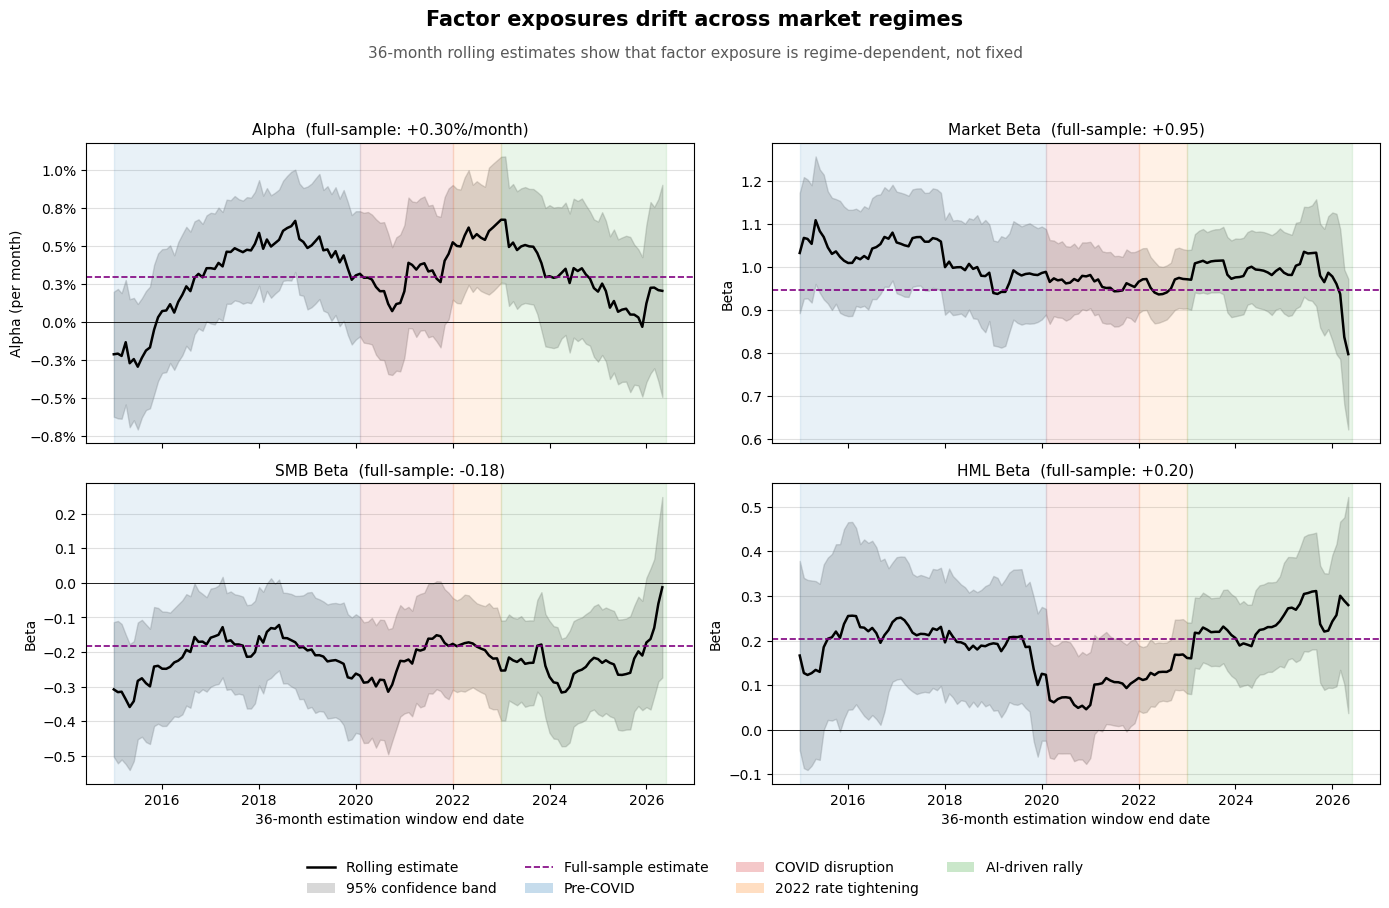

In [9]:
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ts = rolling_params.index.to_timestamp()
inv = {v: k for k, v in PARAM_NAMES.items()}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, col in zip(axes.ravel(), rolling_params.columns):
    est, se = rolling_params[col], rolling_se[col]
    ax.plot(ts, est, lw=1.8, color="black")
    ax.fill_between(ts, est - 1.96 * se, est + 1.96 * se, color="grey", alpha=0.3)
    ref = full_model.params[inv[col]]
    ax.axhline(ref, color="purple", ls="--", lw=1.2)
    shade_regimes(ax)

    if col == "Alpha":
        ax.set_title(f"Alpha  (full-sample: {ref:+.2%}/month)", fontsize=11)
        ax.set_ylabel("Alpha (per month)")
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
        ax.axhline(0, color="black", lw=0.6)
    else:
        ax.set_title(f"{col}  (full-sample: {ref:+.2f})", fontsize=11)
        ax.set_ylabel("Beta")
        if col != "Market Beta":
            # market beta never approaches zero — omitting the zero line keeps
            # the y-axis tight around the data so the variation is visible
            ax.axhline(0, color="black", lw=0.6)

    ax.grid(axis="y", color="0.88", lw=0.8)
    ax.set_axisbelow(True)

for ax in axes[-1]:
    ax.set_xlabel("36-month estimation window end date")

legend_items = [
    Line2D([], [], color="black", lw=1.8, label="Rolling estimate"),
    Patch(facecolor="grey", alpha=0.3, label="95% confidence band"),
    Line2D([], [], color="purple", ls="--", lw=1.2, label="Full-sample estimate"),
] + [Patch(facecolor=c, alpha=0.25, label=name) for name, (_, _, c) in REGIMES.items()]
fig.legend(handles=legend_items, loc="lower center", ncol=4, frameon=False, fontsize=10)

fig.suptitle("Factor exposures drift across market regimes",
             fontsize=15, fontweight="bold", y=0.995)
fig.text(0.5, 0.955,
         "36-month rolling estimates show that factor exposure is regime-dependent, not fixed",
         ha="center", va="top", fontsize=11, color="0.35")
fig.tight_layout(rect=[0, 0.07, 1, 0.925])
plt.show()

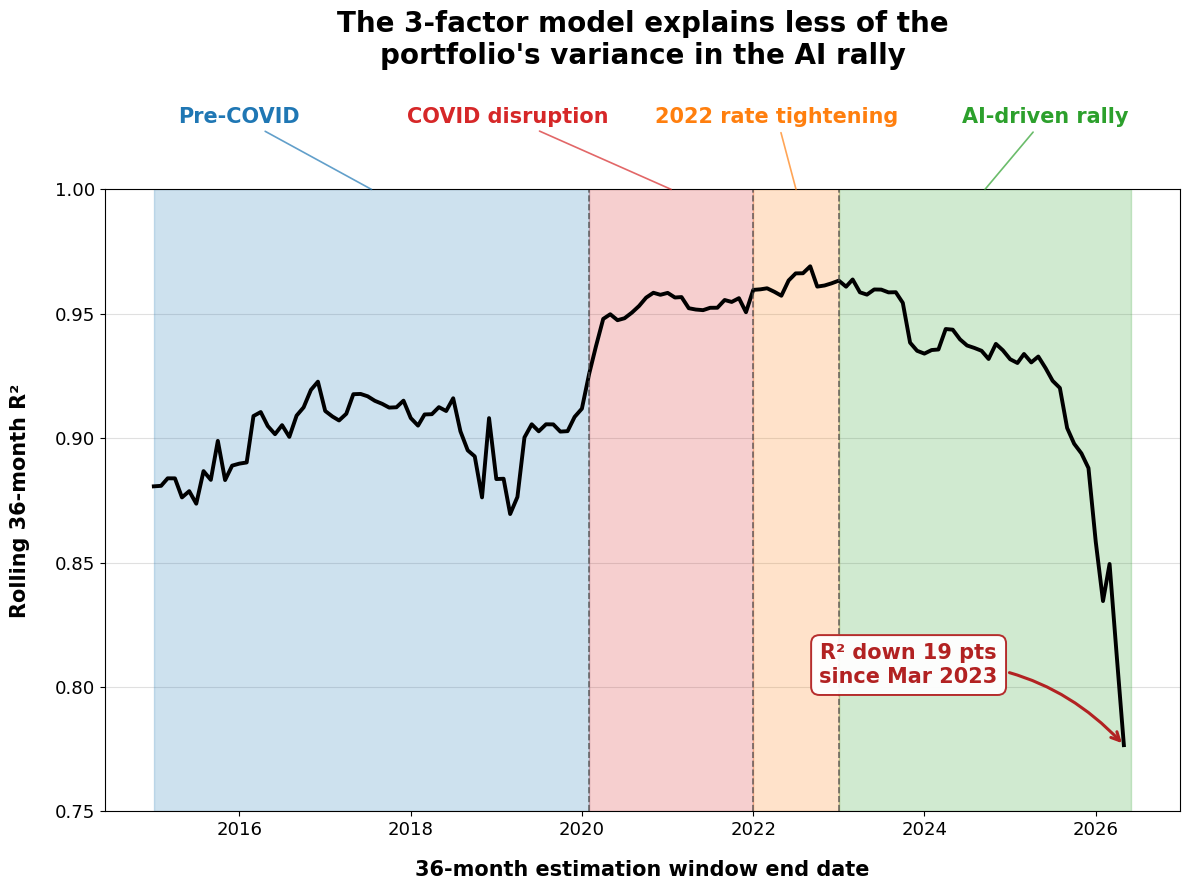

In [10]:
import matplotlib.dates as mdates

REGIME_LABELS = {
    "Pre-COVID": "Pre-COVID",
    "COVID disruption": "COVID disruption",
    "2022 rate tightening": "2022 rate tightening",
    "AI-driven rally": "AI-driven rally",
}

# Square-ish canvas (1200x900) and larger fonts throughout — this chart is designed
# to survive being shrunk to a LinkedIn-feed thumbnail, not just a full-size read.
fig, ax = plt.subplots(figsize=(12, 9))
ax.plot(rolling_r2.index.to_timestamp(), rolling_r2, color="black", lw=2.8)

# Deeper band fills + dashed boundaries so adjacent regimes (e.g. COVID vs. 2022
# tightening) stay distinguishable even at low contrast / small size.
band_alpha = 0.22
for name, (s, e, c) in REGIMES.items():
    start = pd.Period(s, "M").to_timestamp()
    end = pd.Period(e, "M").to_timestamp(how="end")
    ax.axvspan(start, end, color=c, alpha=band_alpha)

boundaries = [pd.Period(s, "M").to_timestamp() for s, _, _ in list(REGIMES.values())[1:]]
for b in boundaries:
    ax.axvline(b, color="0.3", ls="--", lw=1.2, alpha=0.8)

# All four regime labels sit in a single row in the margin above the axes,
# evenly spaced left-to-right in regime order, with a thin leader line down to
# the actual band center. The "2022 rate tightening" band is only 12 months
# wide and sits right next to "COVID disruption" — too narrow/close for
# same-height labels to be centered directly over their own bands without
# overlapping, so a leader line decouples label position from band width.
label_x_frac = [0.125, 0.375, 0.625, 0.875]
label_y_frac = 1.10
for i, (name, (s, e, c)) in enumerate(REGIMES.items()):
    start = pd.Period(s, "M").to_timestamp()
    end = pd.Period(e, "M").to_timestamp(how="end")
    mid = mdates.date2num(start + (end - start) / 2)
    ax.annotate(REGIME_LABELS[name],
                xy=(mid, 1.0), xycoords=ax.get_xaxis_transform(),
                xytext=(label_x_frac[i], label_y_frac), textcoords=ax.transAxes,
                ha="center", va="bottom", fontsize=15, fontweight="bold",
                color=c, clip_on=False, annotation_clip=False,
                arrowprops=dict(arrowstyle="-", color=c, lw=1.2, alpha=0.7,
                                 shrinkA=2, shrinkB=0))

# Callout on the recent drop — the whole story of this chart, so make it
# impossible to miss on a fast scroll.
peak_period = rolling_r2.loc["2023":].idxmax()
peak_val = rolling_r2.loc[peak_period]
last_period = rolling_r2.index[-1]
last_val = rolling_r2.iloc[-1]
drop_pts = (peak_val - last_val) * 100

ax.annotate(
    f"R² down {drop_pts:.0f} pts\nsince {peak_period.strftime('%b %Y')}",
    xy=(last_period.to_timestamp(), last_val),
    xytext=(-155, 45), textcoords="offset points",
    fontsize=15, fontweight="bold", color="firebrick", ha="center",
    arrowprops=dict(arrowstyle="->", color="firebrick", lw=2.2,
                     connectionstyle="arc3,rad=-0.25"),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="firebrick", lw=1.4, alpha=0.95),
)

ax.set_title("The 3-factor model explains less of the\nportfolio's variance in the AI rally",
             fontsize=20, fontweight="bold", pad=90)
ax.set_ylabel("Rolling 36-month R²", fontsize=15, fontweight="bold", labelpad=18)
ax.set_xlabel("36-month estimation window end date", fontsize=15, fontweight="bold", labelpad=15)
ax.tick_params(axis="both", labelsize=13)
ax.set_ylim(0.75, 1)
ax.grid(axis="y", color="0.88", lw=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## Step 5 — Factor exposures by market regime

Separate OLS regressions on each sub-period, with Newey–West HAC p-values in brackets next to each
estimate. **Caveats:** the 2022 regime has only ~12 monthly observations for a 4-parameter
regression, so treat its estimates as indicative, not precise — this is exactly the
estimation-window fragility the project is designed to highlight. HAC standard errors are also
unreliable in samples that small, so the short-regime p-values are at best rough guides.

In [11]:
def fit_regime(sub):
    return sm.OLS(sub["Rp_excess"], sm.add_constant(sub[FACTORS])).fit(
        cov_type="HAC", cov_kwds={"maxlags": nw_lags(len(sub))})

def row(name, m):
    out = {"Regime": name, "Months": int(m.nobs),
           "Alpha (ann.)": f"{(1 + m.params['const'])**12 - 1:+.2%} [{m.pvalues['const']:.3f}]"}
    for f, label in [("Mkt-RF", "Mkt Beta"), ("SMB", "SMB Beta"), ("HML", "HML Beta")]:
        out[label] = f"{m.params[f]:+.3f} [{m.pvalues[f]:.3f}]"
    out["R²"] = round(m.rsquared, 3)
    return out

rows = [row(name, fit_regime(data.loc[pd.Period(s, "M"): pd.Period(e, "M")]))
        for name, (s, e, _) in REGIMES.items()]
rows.append(row("Full sample", full_model))

regime_table = pd.DataFrame(rows).set_index("Regime")
print("Estimates shown as: coefficient [Newey-West p-value]")
regime_table

Estimates shown as: coefficient [Newey-West p-value]


,Months,Alpha (ann.),Mkt Beta,SMB Beta,HML Beta,R²
Regime,,,,,,
Pre-COVID,61,+5.06% [0.000],+1.007 [0.000],-0.206 [0.000],+0.199 [0.000],0.9120
COVID disruption,23,+7.34% [0.013],+0.944 [0.000],-0.172 [0.016],+0.103 [0.020],0.9650
2022 rate tightening,12,+11.16% [0.000],+1.050 [0.000],-0.195 [0.192],+0.238 [0.014],0.9730
AI-driven rally,41,+2.75% [0.356],+0.821 [0.000],-0.089 [0.426],+0.255 [0.000],0.7720
Full sample,172,+3.65% [0.001],+0.946 [0.000],-0.183 [0.000],+0.202 [0.000],0.8980


### Stability summary

Dispersion of the rolling estimates. A rolling beta whose standard deviation is large relative to
its full-sample standard error is *statistically* unstable, not just noisy.

In [12]:
summary = pd.DataFrame({
    "Mean": rolling_params.mean(), "Std": rolling_params.std(),
    "Min": rolling_params.min(), "Max": rolling_params.max(),
    "Range": rolling_params.max() - rolling_params.min(),
})
summary["Full-sample SE"] = [full_model.bse[k] for k in PARAM_NAMES]
summary["Std / SE"] = summary["Std"] / summary["Full-sample SE"]
summary

,Mean,Std,Min,Max,Range,Full-sample SE,Std / SE
Alpha,0.0031,0.0023,-0.0030,0.0067,0.0097,0.0009,2.4382
Market Beta,0.9956,0.0447,0.7973,1.1087,0.3113,0.0369,1.2119
SMB Beta,-0.2182,0.0556,-0.3588,-0.0126,0.3461,0.0433,1.2848
HML Beta,0.1862,0.0632,0.0459,0.3109,0.2650,0.0378,1.6711


## Interpretation

Things to look for in the results above:

- **Market beta** is usually the most stable loading for a diversified large-cap portfolio
  (close to 1, narrow confidence band), but watch for a jump when the COVID-crash months enter
  or leave the 36-month window.
- **SMB beta** should be persistently *negative* for a large-cap portfolio — a mechanical size
  tilt. Its stability tells you whether the size exposure is structural or regime-dependent.
- **HML beta** is typically the least stable loading. In this sample it is *positive*
  (~+0.2 full-sample, and if anything higher in the 2022 tightening and AI-rally windows): despite
  holding growth mega-caps, the portfolio's equal weighting gives substantial weight to value-type
  names (XOM, CVX, JPM, GS, KO, PG, CAT), so it behaves more like a value portfolio than a
  cap-weighted growth index would. This is a useful illustration that factor exposure comes from
  *weights*, not just from holding famous growth stocks. Watch how the loading jumps around the
  2022 value rotation.
- **Rolling R²** dropping means the three factors explain less of the portfolio's variance —
  idiosyncratic (stock-specific) risk is dominating in that window.
- In the **Std / SE** column, values well above ~2 suggest the loading moves by more than its own
  estimation uncertainty, i.e. genuine time variation rather than sampling noise. (Interpret this
  loosely: because the rolling windows overlap, the rolling estimates are serially dependent and
  this ratio is a heuristic, not a formal test.)
- **Alpha** should be discounted for the survivorship and selection biases discussed in Step 3 —
  the betas, not the intercept, are the credible output of this exercise.

**Implication for portfolio construction:** if loadings drift materially across regimes, risk
models and optimisers calibrated on a single historical window will mis-state factor risk —
the estimation window itself becomes a modelling choice.

## Step 6 — Is the falling R² stock-specific or market-wide?

The rolling R² falls noticeably once the AI-rally months enter the estimation window. Two
competing explanations:

1. **Stock-specific:** a handful of AI winners held in *this* portfolio (NVDA, MSFT, AAPL) became
   dominated by idiosyncratic moves — the model is fine, our sample of 15 names isn't.
2. **Market-wide:** the three-factor model genuinely explained a smaller fraction of equity
   returns during the AI era.

Separating these requires a control. **SPY is not a valid control:** the `Mkt-RF` factor is the
value-weighted return of essentially the whole U.S. market, of which the S&P 500 is roughly 85%
of the capitalisation. Regressing SPY on the factors is close to regressing a variable on itself
— its R² is pinned near 0.99 in every window (verified below) and *cannot* decline, so the
comparison would be one-sided: it would force the stock-specific conclusion regardless of the
truth.

Instead we instrument the question with the full S&P 500 cross-section:

- **Equal-weight 500 portfolio** — fully diversified, but not mechanically the market factor
  (equal weighting creates real SMB/HML tilts), so its R² is free to move.
- **Per-stock rolling R²** across all constituents (Step 7) — did the model's explanatory power
  decline for the cross-section as a whole?
- **1,000 random 15-stock portfolios** (Step 8) — the sampling distribution our actual portfolio
  should be judged against.

In [13]:
import io
import os
import requests

SP500_CACHE = "sp500_prices_cache.csv"

wiki = requests.get("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
                    headers={"User-Agent": "Mozilla/5.0"}, timeout=30).text
sp500_tickers = sorted(pd.read_html(io.StringIO(wiki))[0]["Symbol"]
                       .str.replace(".", "-", regex=False))   # Yahoo uses '-' for share classes

if os.path.exists(SP500_CACHE):
    sp_prices = pd.read_csv(SP500_CACHE, index_col=0, parse_dates=True)
else:
    sp_prices = yf.download(sp500_tickers, start=START, interval="1mo",
                            auto_adjust=True, progress=False)["Close"]
    sp_prices.to_csv(SP500_CACHE)

sp_rets = sp_prices.pct_change().dropna(how="all")
sp_rets.index = sp_rets.index.to_period("M")
sp_rets = sp_rets.reindex(data.index)   # align to the factor sample from Step 2

print(f"{len(sp500_tickers)} constituents; panel {sp_rets.shape[0]} months x "
      f"{sp_rets.shape[1]} stocks ({sp_rets.index[0]} to {sp_rets.index[-1]})")

503 constituents; panel 172 months x 503 stocks (2012-02 to 2026-05)


### Universe and survivorship

Two deliberate restrictions on the panel:

- **Full-history names only.** Constituents that IPO'd or were spun off after 2012 (ABNB, GEHC,
  KVUE, …) enter the panel partway through; a naive equal-weight mean over available names would
  change composition over time, and that drift would show up in the rolling estimates as spurious
  "instability". Restricting to names with complete history (~438 of 503) also keeps the bootstrap
  portfolios in Step 8 comparable to the actual 15-stock portfolio, whose names all have full
  history.
- **Survivorship remains, in a different shape.** Today's membership list is backfilled to 2012,
  so firms that fell out of the index (or were delisted — absent from Yahoo Finance entirely) are
  excluded by construction. This inflates average returns and alpha, as in Step 3; the R²
  *dynamics* studied here are less affected, but the bootstrap fan is drawn from a survivor
  universe and should be read with that in mind. Fixing it properly needs point-in-time
  constituents and delisted price data (CRSP), which free sources don't provide.

Prices are cached to `sp500_prices_cache.csv` next to this notebook — delete the file to force a
fresh constituent scrape and re-download.

In [14]:
full_hist = sp_rets.columns[sp_rets.notna().all()]
sp_full = sp_rets[full_hist]

def ff3_roll_r2(excess):
    """Rolling 36-month FF3 R² for an excess-return series on the aligned sample."""
    return RollingOLS(excess, X, window=WINDOW).fit().rsquared.dropna()

ew500_r2 = ff3_roll_r2(sp_full.mean(axis=1) - data["RF"])

# SPY footnote: the regression is near-tautological (the S&P 500 is ~85% of the market cap
# behind Mkt-RF), so its R² is pinned at ~0.99 in every window and cannot serve as a control
spy = yf.download("SPY", start=START, interval="1mo", auto_adjust=True,
                  progress=False)["Close"].squeeze()
spy_ret = spy.pct_change()
spy_ret.index = spy_ret.index.to_period("M")
spy_r2 = ff3_roll_r2(spy_ret.reindex(data.index) - data["RF"])

print(f"Full-history universe: {len(full_hist)} of {sp_rets.shape[1]} current constituents")
print(f"EW-500 rolling R²: min {ew500_r2.min():.3f}, max {ew500_r2.max():.3f}, "
      f"last {ew500_r2.iloc[-1]:.3f}")
print(f"SPY    rolling R²: min {spy_r2.min():.3f}, max {spy_r2.max():.3f}   "
      f"<- pinned ~=1 by construction: uninformative as a control")

Full-history universe: 438 of 503 current constituents
EW-500 rolling R²: min 0.889, max 0.986, last 0.889
SPY    rolling R²: min 0.993, max 0.999   <- pinned ~=1 by construction: uninformative as a control


## Step 7 — Cross-sectional R²: does the model explain individual stocks less well?

The same rolling regression run on every full-history constituent, tracked as a cross-sectional
distribution. Note the *level* is far lower than for any portfolio (typically 0.2–0.5):
idiosyncratic risk dominates single names, which is exactly why Fama and French sort stocks into
portfolios before estimating factor models. The signal here is the **trend**, not the level — a
genuine market-wide decline in the model's explanatory power should pull the whole distribution
down, not just one hand-picked portfolio.

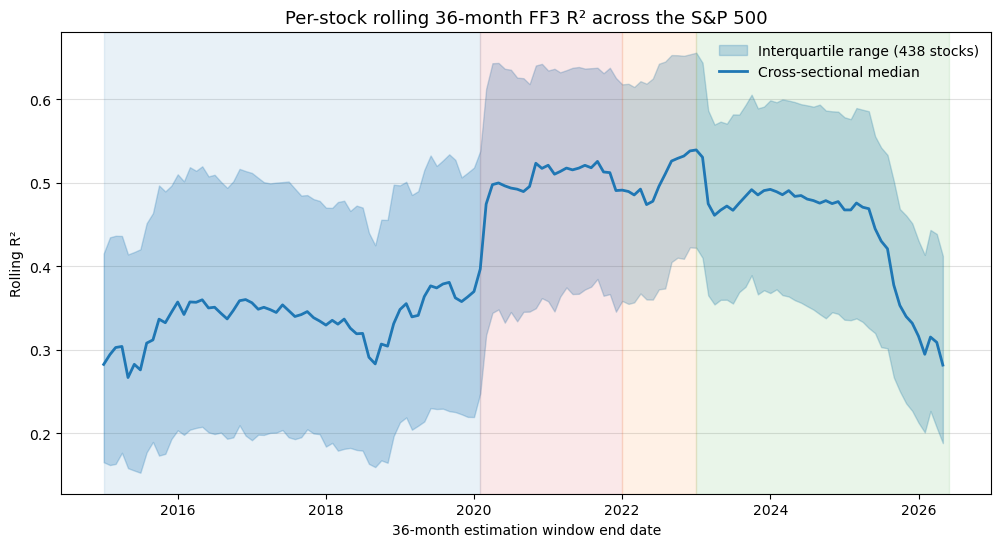

Median per-stock R²: pre-AI (to 2022-12) 0.397, AI rally (2023-01 on) 0.444


In [15]:
stock_r2 = pd.DataFrame({t: RollingOLS(sp_full[t] - data["RF"], X, window=WINDOW).fit().rsquared
                         for t in full_hist}).dropna(how="all")

xs = stock_r2.quantile([0.25, 0.50, 0.75], axis=1).T
ts_xs = xs.index.to_timestamp()

fig, ax = plt.subplots()
ax.fill_between(ts_xs, xs[0.25], xs[0.75], color="tab:blue", alpha=0.25,
                label=f"Interquartile range ({len(full_hist)} stocks)")
ax.plot(ts_xs, xs[0.50], color="tab:blue", lw=2, label="Cross-sectional median")
shade_regimes(ax)
ax.set_title("Per-stock rolling 36-month FF3 R² across the S&P 500", fontsize=13)
ax.set_ylabel("Rolling R²")
ax.set_xlabel("36-month estimation window end date")
ax.grid(axis="y", color="0.88", lw=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.show()

med = xs[0.50]
print(f"Median per-stock R²: pre-AI (to 2022-12) {med[:pd.Period('2022-12','M')].mean():.3f}, "
      f"AI rally (2023-01 on) {med[pd.Period('2023-01','M'):].mean():.3f}")

## Step 8 — Bootstrap: where does our portfolio sit among random 15-stock portfolios?

The direct test. We draw 1,000 equal-weight portfolios of 15 names at random from the
full-history universe and run the identical rolling regression on each, giving a sampling
distribution ("fan") of rolling-R² paths for a portfolio of exactly our size. This controls for
the mechanical fact that any 15-stock portfolio is noisier than a 500-stock index — some R² gap
versus the equal-weight 500 is pure diversification arithmetic, not evidence about our picks.

How to read the fan chart:

- **The whole fan shifts down in the AI rally** → the three-factor model explained less of
  *any* 15-stock portfolio's returns in that period — a market-wide story.
- **Our portfolio's path falls into the left tail of the fan** → the decline is specific to our
  names (the AI mega-caps) — a stock-selection story.
- Both can be true at once; the percentile-rank table below separates the two components.

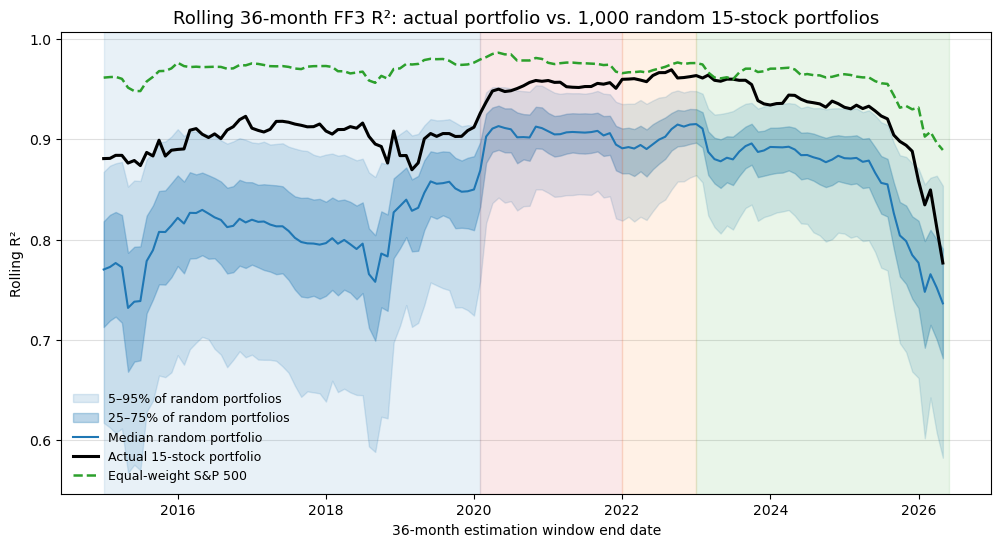

Actual portfolio's percentile rank within the bootstrap fan (mean per regime):
  Pre-COVID               95.1%
  COVID disruption        96.5%
  2022 rate tightening    99.7%
  AI-driven rally         96.2%
  Last 12 windows         92.0%

Rolling R², post-2023 peak to latest window:
  Actual portfolio         peak 0.964 (2023-03) -> last 0.777   drop 0.187
  Median random portfolio  peak 0.915 (2023-01) -> last 0.736   drop 0.179
  Equal-weight S&P 500     peak 0.976 (2023-01) -> last 0.889   drop 0.087


In [16]:
N_BOOT = 1000
rng = np.random.default_rng(42)   # fixed seed so the fan is reproducible

boot_r2 = pd.DataFrame({
    i: ff3_roll_r2(sp_full.iloc[:, rng.choice(len(full_hist), size=len(TICKERS),
                                              replace=False)].mean(axis=1) - data["RF"])
    for i in range(N_BOOT)
})

fan = boot_r2.quantile([0.05, 0.25, 0.50, 0.75, 0.95], axis=1).T
ts_fan = fan.index.to_timestamp()

fig, ax = plt.subplots()
ax.fill_between(ts_fan, fan[0.05], fan[0.95], color="tab:blue", alpha=0.15,
                label="5–95% of random portfolios")
ax.fill_between(ts_fan, fan[0.25], fan[0.75], color="tab:blue", alpha=0.30,
                label="25–75% of random portfolios")
ax.plot(ts_fan, fan[0.50], color="tab:blue", lw=1.5, label="Median random portfolio")
ax.plot(rolling_r2.index.to_timestamp(), rolling_r2, color="black", lw=2.2,
        label="Actual 15-stock portfolio")
ax.plot(ew500_r2.index.to_timestamp(), ew500_r2, color="tab:green", ls="--", lw=1.8,
        label="Equal-weight S&P 500")
shade_regimes(ax)
ax.set_title(f"Rolling 36-month FF3 R²: actual portfolio vs. {N_BOOT:,} random "
             f"15-stock portfolios", fontsize=13)
ax.set_ylabel("Rolling R²")
ax.set_xlabel("36-month estimation window end date")
ax.grid(axis="y", color="0.88", lw=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower left", fontsize=9)
plt.show()

# percentile rank = fraction of random portfolios with LOWER R² than the actual portfolio
pct_rank = boot_r2.lt(rolling_r2, axis=0).mean(axis=1)

print("Actual portfolio's percentile rank within the bootstrap fan (mean per regime):")
for name, (s, e, _) in REGIMES.items():
    sub = pct_rank[pd.Period(s, "M"): pd.Period(e, "M")]
    if len(sub):
        print(f"  {name:22s} {sub.mean():6.1%}")
print(f"  {'Last 12 windows':22s} {pct_rank.iloc[-12:].mean():6.1%}")

# regime-mean R² masks the decline (it is concentrated late in the AI window),
# so compare each series' post-2023 peak with the latest window instead
def peak_to_last(series):
    peak = series[pd.Period("2023-01", "M"):].max()
    return (f"peak {peak:.3f} ({series[pd.Period('2023-01','M'):].idxmax()}) -> "
            f"last {series.iloc[-1]:.3f}   drop {peak - series.iloc[-1]:.3f}")

print("\nRolling R², post-2023 peak to latest window:")
print(f"  Actual portfolio         {peak_to_last(rolling_r2)}")
print(f"  Median random portfolio  {peak_to_last(fan[0.50])}")
print(f"  Equal-weight S&P 500     {peak_to_last(ew500_r2)}")

### Verdict: the decline is market-wide, not stock-specific

(Numbers below are from the June 2026 run; they will drift slightly as new months arrive.)

- **The whole fan fell, by about as much as our portfolio.** From its post-2023 peak to the
  latest window, the actual portfolio's rolling R² dropped ~0.19 (0.96 → 0.78) — and the *median
  random 15-stock portfolio* dropped ~0.18 (0.92 → 0.74). The decline is a property of the
  cross-section, not of our particular names.
- **Our portfolio never fell into the left tail.** It sits around the 95th percentile of the fan
  in every regime, including the AI rally (~92% over the last 12 windows). If the AI mega-caps in
  our list were the culprits, the black line would have sunk *through* the fan; instead it rode
  down *with* it. (The mild slip in percentile rank in the very last windows hints at a small
  stock-specific component on top, but it is second-order.)
- **Even the equal-weight 500 confirms it.** The fully diversified portfolio — where no single
  stock's idiosyncratic move can matter — lost ~0.09 of R² and now sits at its sample minimum.
- **Why our portfolio is *better* explained than random ones, by the way:** the 15 names were
  deliberately spread across sectors, which diversifies idiosyncratic risk more effectively than
  a random draw. That is what a 95th-percentile rank in the fan means — and it is worth a caveat
  that random equal-weight draws are not sector-balanced.
- **SPY, as predicted, is silent:** its rolling R² never leaves the 0.99–1.00 band and carries no
  information about the model's health.

So the supported claim is the stronger one: **during the late AI rally, the three-factor model
explained a materially smaller fraction of monthly returns for essentially any portfolio of
large-cap U.S. stocks** — idiosyncratic, stock-specific variance grew across the whole
cross-section. A caveat cuts both ways: the fan is drawn from today's surviving constituents, so
the market-wide conclusion technically applies to the survivor universe, but since survivorship
would if anything bias *toward* well-behaved factor exposures, the observed decline is unlikely
to be an artifact of it.